In [18]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


file_path=r"D:\DS Assignment\Clustering\Clustering\EastWestAirlines.xlsx"
df = pd.read_excel(file_path, sheet_name=1, engine='openpyxl')
df.head(), df.shape


(   ID#  Balance  Qual_miles  cc1_miles  cc2_miles  cc3_miles  Bonus_miles  \
 0    1    28143           0          1          1          1          174   
 1    2    19244           0          1          1          1          215   
 2    3    41354           0          1          1          1         4123   
 3    4    14776           0          1          1          1          500   
 4    5    97752           0          4          1          1        43300   
 
    Bonus_trans  Flight_miles_12mo  Flight_trans_12  Days_since_enroll  Award?  
 0            1                  0                0               7000       0  
 1            2                  0                0               6968       0  
 2            4                  0                0               7034       0  
 3            1                  0                0               6952       0  
 4           26               2077                4               6935       1  ,
 (3999, 12))

In [ ]:

df.info()
df.describe().T
df.isna().sum()  
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


np.int64(0)

In [ ]:
df2 = df.copy()

if 'ID' in df2.columns:
    df2 = df2.drop('ID', axis=1)

num_cols = df2.select_dtypes(include=np.number).columns.tolist()
df2[num_cols] = df2[num_cols].fillna(df2[num_cols].median())

cat_cols = df2.select_dtypes(include=['object','category']).columns.tolist()
df2 = pd.get_dummies(df2, columns=cat_cols, drop_first=True)

def remove_outliers_iqr(df_in, cols):
    df_out = df_in.copy()
    for c in cols:
        Q1 = df_out[c].quantile(0.25)
        Q3 = df_out[c].quantile(0.75)
        IQR = Q3 - Q1
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        df_out = df_out[(df_out[c] >= low) & (df_out[c] <= high)]
    return df_out


# df2 = remove_outliers_iqr(df2, num_cols)


scaler = StandardScaler()
X = scaler.fit_transform(df2[num_cols])
X = pd.DataFrame(X, columns=num_cols)


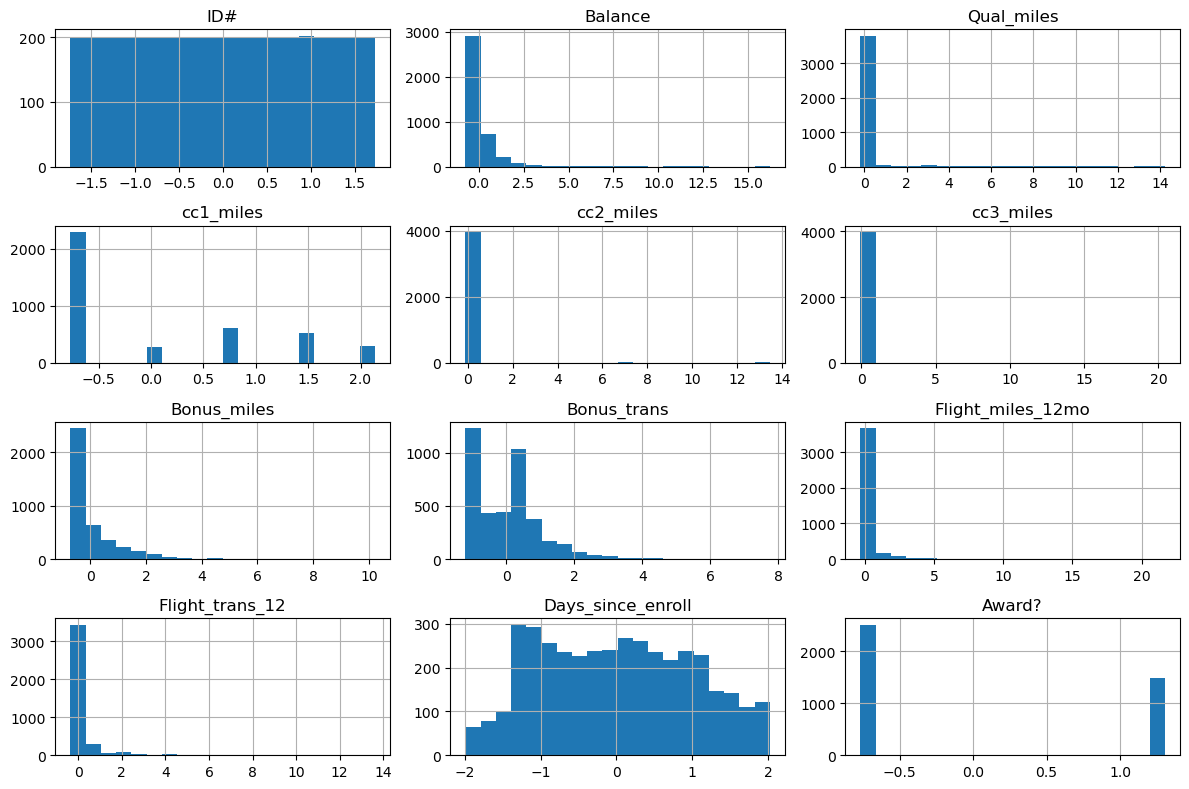

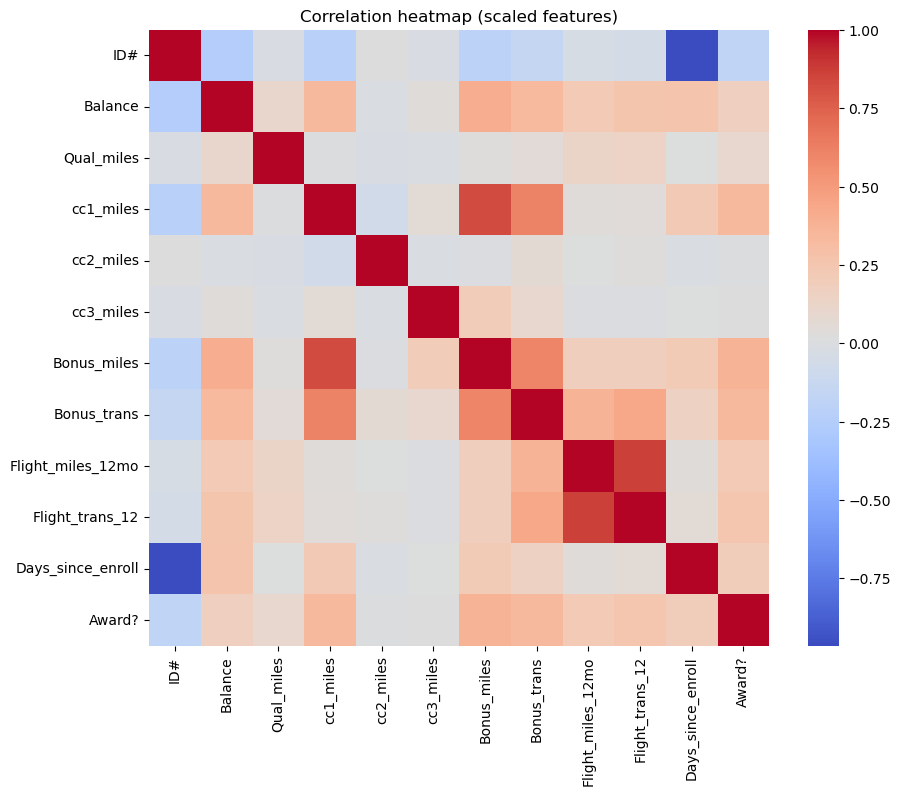

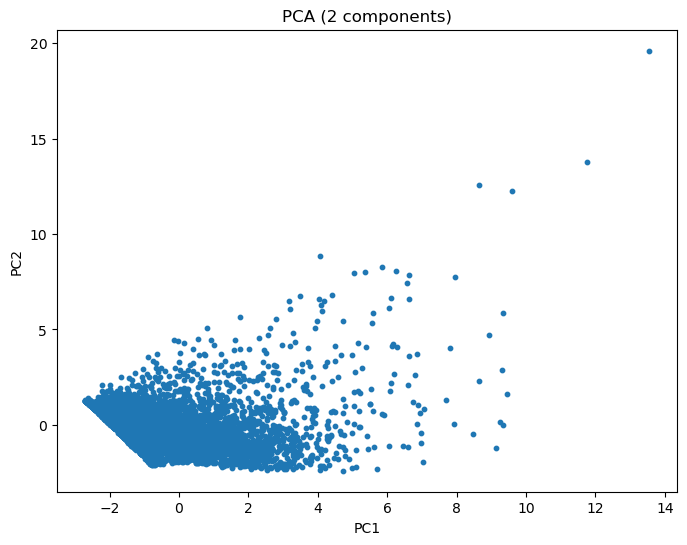

In [ ]:
X[num_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()

plt.figure(figsize=(10,8))
sns.heatmap(pd.DataFrame(X).corr(), annot=False, cmap='coolwarm')
plt.title('Correlation heatmap (scaled features)')
plt.show()

pca = PCA(n_components=2)
pc = pca.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(pc[:,0], pc[:,1], s=10)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (2 components)')
plt.show()


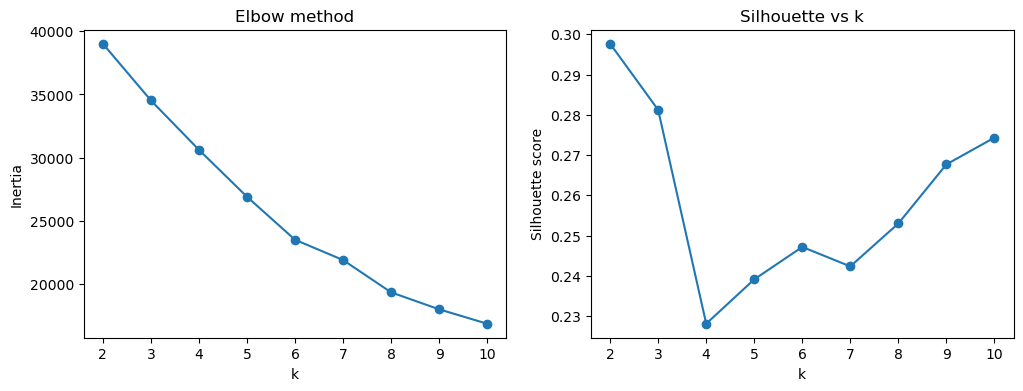

In [ ]:
inertia = []
sil = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, labels))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(K_range, inertia, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(K_range, sil, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette vs k')
plt.show()


In [ ]:
best_k = 4  
km = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_km = km.fit_predict(X)

df['cluster_kmeans'] = labels_km
df.groupby('cluster_kmeans')[num_cols].mean().T  


cluster_kmeans,0,1,2,3
ID#,3133.055231,1532.492552,1094.120278,1751.262821
Balance,39898.197531,127734.216485,56985.831149,194803.871795
Qual_miles,106.287199,160.202582,96.370085,810.397436
cc1_miles,1.388564,3.959285,1.363917,2.198718
cc2_miles,1.016894,1.001986,1.018504,1.038462
cc3_miles,1.000000,1.047666,1.000771,1.000000
Bonus_miles,6271.906433,45887.323734,5886.720894,32475.410256
Bonus_trans,7.831709,19.507448,7.996916,27.737179
Flight_miles_12mo,201.923977,371.256207,227.814187,5510.717949
Flight_trans_12,0.600390,1.117180,0.703932,16.224359


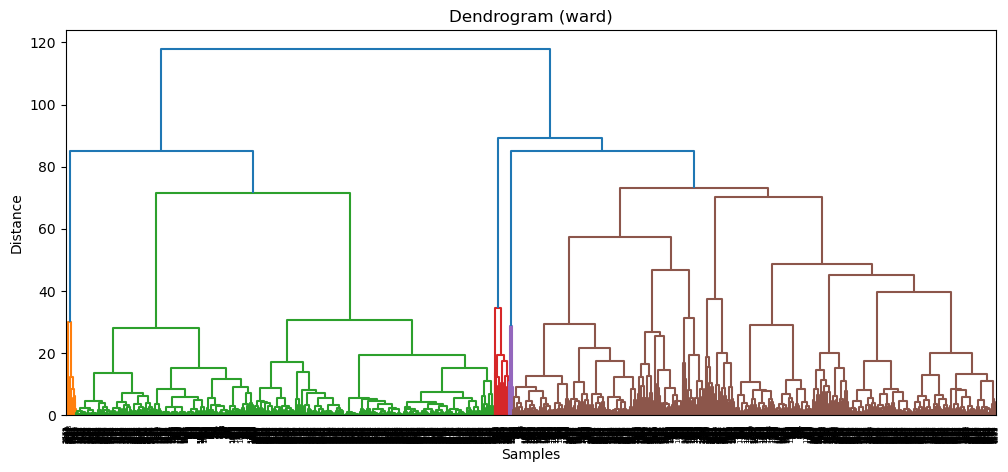

cluster_hier,0,1,2,3
ID#,2269.372093,2388.934444,1752.952381,1695.729575
Balance,68876.581395,38220.721111,160067.206349,101523.403727
Qual_miles,23.255814,9.431667,573.587302,249.498806
cc1_miles,1.139535,1.183889,2.507937,2.817965
cc2_miles,2.348837,1.000000,1.000000,1.000000
cc3_miles,1.000000,1.000000,1.000000,1.023411
Bonus_miles,14689.837209,3770.797222,42723.841270,27927.157191
Bonus_trans,17.534884,6.238333,34.142857,15.414238
Flight_miles_12mo,582.627907,113.728333,8148.619048,523.954133
Flight_trans_12,2.209302,0.383889,22.444444,1.573340


In [ ]:
import scipy.cluster.hierarchy as sch

Z = linkage(X, method='ward')  
plt.figure(figsize=(12,5))
dendrogram(Z, truncate_mode='level', p=30)
plt.title('Dendrogram (ward)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

from scipy.cluster.hierarchy import fcluster
k_h = 4  
labels_h = fcluster(Z, k_h, criterion='maxclust') - 1  
df['cluster_hier'] = labels_h
df.groupby('cluster_hier')[num_cols].mean().T


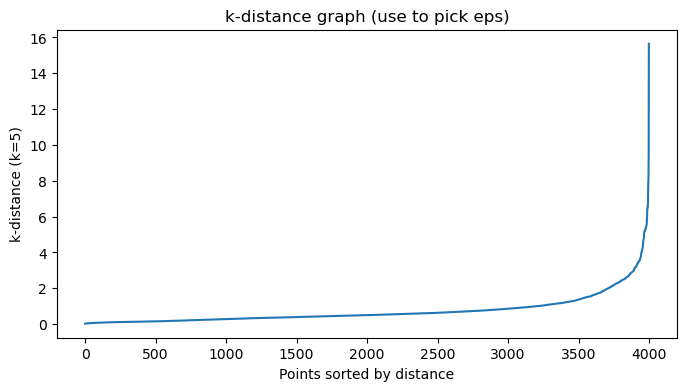

In [ ]:

from sklearn.neighbors import NearestNeighbors


min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, -1])
plt.figure(figsize=(8,4))
plt.plot(distances)
plt.ylabel('k-distance (k=%d)'%min_samples)
plt.xlabel('Points sorted by distance')
plt.title('k-distance graph (use to pick eps)')
plt.show()


In [ ]:
eps_val = 0.6  
db = DBSCAN(eps=eps_val, min_samples=min_samples)
labels_db = db.fit_predict(X)

np.unique(labels_db, return_counts=True)

mask = labels_db != -1
if len(set(labels_db[mask])) > 1:
    print("Silhouette:", silhouette_score(X[mask], labels_db[mask]))
df['cluster_db'] = labels_db
df.groupby('cluster_db')[num_cols].mean().T


Silhouette: 0.026166151319422692


cluster_db,-1,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
ID#,1770.758908,2339.609939,1994.691489,1677.304965,1859.102273,1983.544355,1479.758621,313.3,166.4,286.857143,349.833333,2193.541667,2190.617021,1302.482759,2851.571429,3336.4,3822.142857,3908.6
Balance,137050.575436,29022.848877,30048.315603,60387.439716,41697.346591,76107.108871,104053.008621,131803.1,200953.0,17605.571429,50728.000000,59704.108333,29355.297872,88101.620690,123403.714286,26077.8,47279.000000,96205.2
Qual_miles,436.932525,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0
cc1_miles,2.702047,1.000000,1.000000,4.000000,3.000000,3.000000,4.000000,2.0,3.0,2.000000,2.000000,2.000000,2.000000,5.000000,5.000000,1.0,3.000000,4.0
cc2_miles,1.040182,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.0,1.000000,1.0
cc3_miles,1.037149,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.0
Bonus_miles,32577.062926,1972.669843,3888.255319,37443.297872,18687.977273,18081.044355,36231.810345,8168.9,18101.6,8632.142857,10622.500000,8412.950000,9470.723404,62593.655172,60030.714286,7392.0,18041.857143,38691.4
Bonus_trans,18.070508,4.870660,5.053191,15.943262,15.437500,14.693548,15.887931,10.5,14.0,13.571429,21.500000,12.600000,13.808511,17.206897,13.571429,11.8,33.571429,16.2
Flight_miles_12mo,1255.202426,64.985705,167.542553,84.156028,50.000000,42.318548,31.034483,5.0,0.0,0.000000,41.666667,17.783333,23.297872,108.620690,0.000000,0.0,0.000000,0.0
Flight_trans_12,3.674754,0.232131,0.560284,0.283688,0.198864,0.153226,0.094828,0.1,0.0,0.000000,0.166667,0.050000,0.085106,0.379310,0.000000,0.0,0.000000,0.0


In [ ]:

def evaluate_labels(X, labels, name):
    labs = labels
   
    if len(set(labs)) <= 1 or (len(set(labs))==2 and -1 in set(labs) and len(set(labs))==2 and list(set(labs))[0]==-1):
        print(f"{name}: Not enough clusters to evaluate")
        return
    
    mask = labs != -1 if -1 in labs else slice(None)
    sl = silhouette_score(X[mask], np.array(labs)[mask])
    ch = calinski_harabasz_score(X[mask], np.array(labs)[mask])
    dbi = davies_bouldin_score(X[mask], np.array(labs)[mask])
    print(f"{name}: silhouette={sl:.4f}, CH={ch:.2f}, DBI={dbi:.4f}")

evaluate_labels(X.values, labels_km, 'KMeans')
evaluate_labels(X.values, labels_h, 'Hierarchical')
evaluate_labels(X.values, labels_db, 'DBSCAN')


KMeans: silhouette=0.2281, CH=755.57, DBI=1.4272
Hierarchical: silhouette=0.2114, CH=579.65, DBI=1.2966
DBSCAN: silhouette=0.0262, CH=178.24, DBI=1.4674


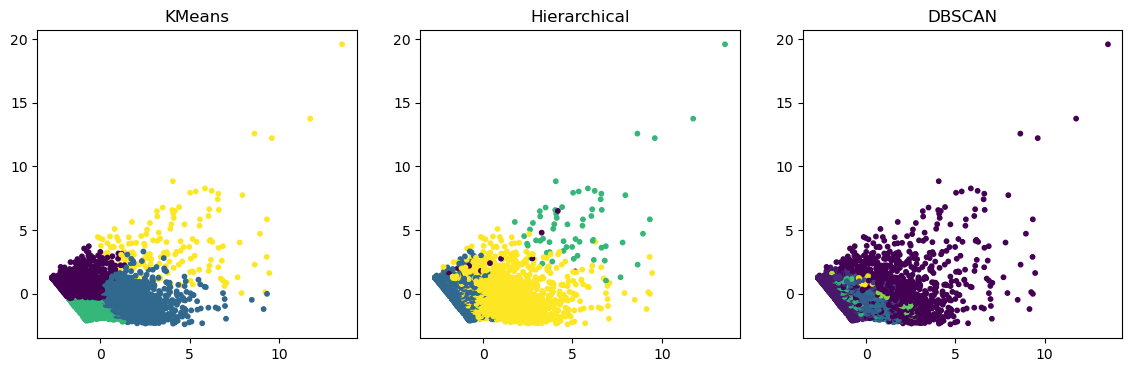

In [ ]:

pca = PCA(n_components=2)
pc = pca.fit_transform(X)

plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.scatter(pc[:,0], pc[:,1], c=labels_km, s=10)
plt.title('KMeans')

plt.subplot(1,3,2)
plt.scatter(pc[:,0], pc[:,1], c=labels_h, s=10)
plt.title('Hierarchical')

plt.subplot(1,3,3)
plt.scatter(pc[:,0], pc[:,1], c=labels_db, s=10)
plt.title('DBSCAN')
plt.show()
